# Groundwater Level Prediction v2 — RF · XGBoost · LightGBM · CatBoost · LSTM

**Target:** `Groundwater Level Telemetry Quadridaily (meter)`

This notebook trains and compares three models on a ~4.7M-row groundwater telemetry
dataset and produces trained artifacts, evaluation metrics, publication-quality plots,
and a prediction demo — end to end, **Run All**, no manual edits.


## Section 1 — Import Libraries

In [1]:
import os, gc, glob, time, random, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import joblib

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# --------------------------------------------------------------- reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

N_CORES = os.cpu_count() or 4
GPUS = tf.config.list_physical_devices("GPU")
print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__} | tf {tf.__version__}")
print(f"CPU cores: {N_CORES} | TensorFlow GPUs: {len(GPUS)} -> {[g.name for g in GPUS]}")

# --------------------------------------------------------------- GPU diagnostics
import subprocess
try:
    smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=15)
    HAS_NVIDIA_GPU = smi.returncode == 0
    print(smi.stdout if HAS_NVIDIA_GPU else smi.stderr)
except FileNotFoundError:
    HAS_NVIDIA_GPU = False

if not HAS_NVIDIA_GPU or not GPUS:
    print("=" * 70)
    print("!! NO GPU DETECTED — this session is running on CPU only.")
    print("!! On Kaggle: Settings (right sidebar) -> Session options ->")
    print("!!   Accelerator -> 'GPU T4 x2' or 'GPU P100', then restart & Run All.")
    print("!! XGBoost and the LSTM will fall back to CPU (much slower).")
    print("=" * 70)
else:
    print("GPU detected: XGBoost will use device='cuda'; the LSTM trains on GPU.")
    print("NOTE: pandas preprocessing, RandomForest, and both hyper-parameter")
    print("searches are CPU-only by design — 0% GPU during those phases is normal.")

pandas 2.3.3 | numpy 2.0.2 | xgboost 3.2.0 | tf 2.20.0
CPU cores: 4 | TensorFlow GPUs: 2 -> ['/physical_device:GPU:0', '/physical_device:GPU:1']
Sun Jul 19 17:05:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Defau

## Configuration

Every knob lives here. Defaults are tuned for the full ~4.7M-row dataset on a Kaggle
T4/P100. A `SMOKE=1` environment variable shrinks everything for a fast dry run.

In [2]:
SMOKE = os.environ.get("SMOKE", "0") == "1"

TARGET_COL = "Groundwater Level Telemetry Quadridaily (meter)"
TIME_COL   = "Data Acquisition Time"
STATION_COL = "Station"
CSV_NAME   = "merged_states_groundwater_population.csv"

# Columns that leak the target (verified: they include the current row's value) -> drop.
LEAK_COLS = [
    "Groundwater Level Telemetry 6 Hourly (meter)",
    "GW_Rolling_Mean_3", "GW_Rolling_STD_3", "GW_Expanding_Mean",
]
# Note: the supplied GW_Lag_1/2/3 are OVERWRITTEN below with freshly recomputed,
# strictly-past values (so they are not dropped here).

SEQ_LEN         = 8          # LSTM look-back window (number of past target values)
TEST_FRAC       = 0.20       # chronological hold-out
VAL_FRAC        = 0.10       # fraction of the training block used for validation
MAX_RF_ROWS     = 300_000    # RandomForest cannot handle 4.7M rows on Kaggle -> subsample
MAX_SEARCH_ROWS = 150_000    # rows used for hyper-parameter search (RF & XGB)
RF_SEARCH_ITERS = 8
XGB_SEARCH_ITERS = 10
XGB_MAX_ESTIMATORS = 4000    # capped by early stopping
LSTM_EPOCHS     = 30
LSTM_BATCH      = 2048

# --- v2: predict the change (delta) and remove impossible jumps ---
DELTA_TARGET       = True    # model predicts (level_t - level_{t-1}); prediction = lag1 + delta
JUMP_DROP_METERS   = 20.0    # |level_t - level_{t-1}| above this is a sensor error -> drop row
DELTA_CLIP_Q       = 0.001   # winsorize training delta to [q, 1-q] so residual outliers don't dominate MSE
HUBER_DELTA        = 1.0     # robustness knob for XGBoost / LightGBM / CatBoost Huber loss
OUTPUT_DIR      = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

if SMOKE:
    SEQ_LEN = 4
    MAX_RF_ROWS = 4_000
    MAX_SEARCH_ROWS = 3_000
    RF_SEARCH_ITERS = 3
    XGB_SEARCH_ITERS = 3
    XGB_MAX_ESTIMATORS = 60
    LSTM_EPOCHS = 3
    LSTM_BATCH = 256

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"SMOKE={SMOKE} | SEQ_LEN={SEQ_LEN} | OUTPUT_DIR={OUTPUT_DIR}")

SMOKE=False | SEQ_LEN=8 | OUTPUT_DIR=/kaggle/working


## Section 2 — Load Dataset

The CSV is located automatically anywhere under `/kaggle/input`. In `SMOKE` mode a
small synthetic dataset with the identical schema is generated so the notebook can be
validated without the real file.

In [3]:
def find_csv(name=CSV_NAME):
    # 1) Exact known path for this dataset (fastest, no directory scan)
    exact = f"/kaggle/input/datasets/sawanade/ground/{name}"
    if os.path.isfile(exact):
        return exact
    # 2) Fallback: search all attached inputs recursively (works if the
    #    mount slug ever changes), then the working directory.
    for base in ("/kaggle/input", "."):
        hits = glob.glob(os.path.join(base, "**", name), recursive=True)
        if hits:
            return sorted(hits)[0]
    return None

def make_synthetic_csv(path, n_stations=6, days=400):
    # Schema-identical synthetic data for SMOKE dry runs
    rng = np.random.default_rng(SEED)
    rows = []
    for s in range(n_stations):
        lat, lon = 24 + rng.random(), 84 + rng.random()
        dates = pd.date_range("2017-06-16", periods=days, freq="D")
        level = 9 + np.cumsum(rng.normal(0, 0.05, days))
        for i, d in enumerate(dates):
            rows.append(dict(
                Station=f"BHGW-{s:04d}", State="Bihar", **{"District LGD Code": 189},
                District="AURANGABAD", Tehsil="BARUN", Block=np.nan,
                Latitude=lat, Longitude=lon,
                **{"Data Acquisition Time": d.strftime("%Y-%m-%d 08:00:00"),
                   TARGET_COL: round(level[i], 2),
                   "Groundwater Level Telemetry 6 Hourly (meter)": np.nan},
                Year=d.year, Month=d.month, Day=d.day, Day_of_Week=d.dayofweek,
                Week_of_Year=d.isocalendar().week, Day_of_Year=np.nan,
                Quarter=d.quarter, Is_Weekend=int(d.dayofweek >= 5),
                Season="Monsoon",
                GW_Lag_1=np.nan, GW_Lag_2=np.nan, GW_Lag_3=np.nan,
                GW_Rolling_Mean_3=np.nan, GW_Rolling_STD_3=np.nan, GW_Expanding_Mean=np.nan,
                population_millions=69.7, pop_density=94163, urban_frac=0.143,
                urban_pct=14.3, urban_pop_M=9.97, rural_pop_M=59.7,
                water_demand_MLD=5.5e6, pop_growth_pct=195.8, pop_index=706.19,
            ))
    pd.DataFrame(rows).to_csv(path, index=False)
    return path

CSV_PATH = find_csv()
if CSV_PATH is None:
    if SMOKE:
        CSV_PATH = make_synthetic_csv(os.path.join(OUTPUT_DIR, CSV_NAME))
        print("SMOKE: generated synthetic dataset ->", CSV_PATH)
    else:
        raise FileNotFoundError(
            f"Could not find {CSV_NAME} under /kaggle/input. "
            "Attach the dataset to this notebook (Add Input)."
        )
print("Reading:", CSV_PATH)

df = pd.read_csv(CSV_PATH, low_memory=False)
print("Raw shape:", df.shape)

Reading: /kaggle/input/datasets/sawanade/ground/merged_states_groundwater_population.csv
Raw shape: (4771516, 35)


In [4]:
# Overview: shape, missing values, dtypes, descriptive stats
print("Shape:", df.shape)
print("\n--- Dtypes ---")
print(df.dtypes)
print("\n--- Missing values (top 20) ---")
miss = df.isna().sum().sort_values(ascending=False)
print(miss[miss > 0].head(20) if (miss > 0).any() else "None")
print("\n--- Descriptive statistics (numeric) ---")
display(df.describe(include=[np.number]).T)

Shape: (4771516, 35)

--- Dtypes ---
Station                                             object
State                                               object
District LGD Code                                    int64
District                                            object
Tehsil                                              object
Block                                               object
Latitude                                           float64
Longitude                                          float64
Data Acquisition Time                               object
Groundwater Level Telemetry Quadridaily (meter)    float64
Groundwater Level Telemetry 6 Hourly (meter)       float64
Year                                                 int64
Month                                                int64
Day                                                  int64
Day_of_Week                                          int64
Week_of_Year                                         int64
Day_of_Year        

,count,mean,std,min,25%,50%,75%,max
District LGD Code,4771516.0,1.589047e+02,1.292820e+02,27.000000,7.500000e+01,1.460000e+02,1.720000e+02,6.620000e+02
Latitude,4771516.0,2.765719e+01,2.057112e+00,24.126959,2.570000e+01,2.717002e+01,2.952222e+01,3.313998e+01
Longitude,4771516.0,7.967869e+01,3.377785e+00,73.954700,7.701596e+01,7.918634e+01,8.239139e+01,8.817000e+01
Groundwater Level Telemetry Quadridaily (meter),1283042.0,-3.915004e+00,3.506356e+01,-158.200000,-1.605000e+01,2.056000e+00,5.490000e+00,9.990000e+02
Groundwater Level Telemetry 6 Hourly (meter),3488463.0,-1.056188e+01,5.485301e+01,-999.999000,-1.767200e+01,-8.976000e+00,-3.342000e+00,1.006110e+03
Year,4771516.0,2.022148e+03,3.103525e+00,1999.000000,2.020000e+03,2.023000e+03,2.024000e+03,2.025000e+03
Month,4771516.0,6.491791e+00,3.404327e+00,1.000000,4.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01
Day,4771516.0,1.572527e+01,8.822936e+00,1.000000,8.000000e+00,1.600000e+01,2.300000e+01,3.100000e+01
Day_of_Week,4771516.0,2.997533e+00,2.000747e+00,0.000000,1.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00
Week_of_Year,4771516.0,2.644597e+01,1.482967e+01,1.000000,1.400000e+01,2.600000e+01,3.900000e+01,5.300000e+01


## Section 3 — Data Cleaning

Downcast to memory-efficient dtypes, parse the timestamp, replace infinities, drop
duplicate and target-null rows. A before/after summary is printed.

In [5]:
def downcast(frame):
    # Shrink numeric columns to the smallest safe dtype
    for c in frame.select_dtypes(include=["float64"]).columns:
        frame[c] = pd.to_numeric(frame[c], downcast="float")
    for c in frame.select_dtypes(include=["int64"]).columns:
        frame[c] = pd.to_numeric(frame[c], downcast="integer")
    return frame

mem_before = df.memory_usage(deep=True).sum() / 1e6
rows_before = len(df)

# Parse timestamp and drop rows we cannot use
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL, TARGET_COL])

# Clean numeric problems
df = df.replace([np.inf, -np.inf], np.nan)
df = df.drop_duplicates()
df = downcast(df)

mem_after = df.memory_usage(deep=True).sum() / 1e6
print("Cleaning summary")
print(f"  rows:   {rows_before:,} -> {len(df):,}  (dropped {rows_before - len(df):,})")
print(f"  memory: {mem_before:,.1f} MB -> {mem_after:,.1f} MB")
print(f"  time range: {df[TIME_COL].min()} -> {df[TIME_COL].max()}")
gc.collect()

Cleaning summary
  rows:   4,771,516 -> 1,283,042  (dropped 3,488,474)
  memory: 2,896.2 MB -> 583.4 MB
  time range: 1999-11-30 00:10:00 -> 2020-12-31 22:15:00


0

## Section 4 — Feature Engineering

**Leak-free lags & rolling stats.** For each station, sorted by time, we compute
`GW_Lag_1 … GW_Lag_SEQ_LEN` with `groupby(station).shift(k)` — every value comes
strictly from the past. The 3-step rolling mean/std are derived from lags 1–3 (again,
past only). Rows without a full look-back window are dropped (a handful per station).

Categorical columns are label-encoded (trees handle integer codes directly).
All-null columns and the supplied leaky columns are removed.

In [6]:
# --- sort by station then time so shifts respect each station's own history
df = df.sort_values([STATION_COL, TIME_COL]).reset_index(drop=True)

g = df.groupby(STATION_COL, sort=False)[TARGET_COL]
lag_cols = [f"GW_Lag_{k}" for k in range(1, SEQ_LEN + 1)]
for k in tqdm(range(1, SEQ_LEN + 1), desc="Building lag features"):
    df[f"GW_Lag_{k}"] = g.shift(k).astype("float32")

# Leak-free rolling stats over the previous 3 observations (from lags, no current value)
df["GW_RollMean_3"] = df[["GW_Lag_1", "GW_Lag_2", "GW_Lag_3"]].mean(axis=1).astype("float32")
df["GW_RollStd_3"]  = df[["GW_Lag_1", "GW_Lag_2", "GW_Lag_3"]].std(axis=1).astype("float32")

# Drop supplied leaky columns (ignore any not present)
df = df.drop(columns=[c for c in LEAK_COLS if c in df.columns])

# Require a full look-back window
df = df.dropna(subset=lag_cols).reset_index(drop=True)

# --- v2: remove physically impossible jumps (sensor glitches / data errors) ---
# A change of more than JUMP_DROP_METERS between consecutive readings is not real groundwater
# movement; such rows corrupt both the target and downstream lags, so drop them.
jump = (df[TARGET_COL] - df["GW_Lag_1"]).abs()
n_before = len(df)
df = df[jump <= JUMP_DROP_METERS].reset_index(drop=True)
print(f"Dropped {n_before - len(df):,} rows with |jump| > {JUMP_DROP_METERS} m "
      f"({(n_before - len(df)) / n_before * 100:.3f}%) as sensor errors")

# Encode categoricals (object columns, excluding identifiers we will not model on)
cat_cols = [c for c in df.select_dtypes(include=["object"]).columns if c != TIME_COL]
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str).fillna("UNKNOWN"))
    encoders[c] = le

# Drop columns that are entirely null (e.g. Day_of_Year in some extracts)
allnull = [c for c in df.columns if df[c].isna().all()]
if allnull:
    df = df.drop(columns=allnull)
    print("Dropped all-null columns:", allnull)

print("Post-feature-engineering shape:", df.shape)
print("Encoded categoricals:", cat_cols)
gc.collect()

Building lag features:   0%|          | 0/8 [00:00<?, ?it/s]

Dropped 400 rows with |jump| > 20.0 m (0.031%) as sensor errors
Post-feature-engineering shape: (1274062, 38)
Encoded categoricals: ['Station', 'State', 'District', 'Tehsil', 'Block', 'Season']


0

## Section 5 — Train/Test Split (chronological)

Sorted by timestamp, the first 80% is training and the last 20% is the test set.
The most recent `VAL_FRAC` of the training block becomes a validation set for XGBoost
early stopping and the LSTM. Nothing is shuffled.

In [7]:
df = df.sort_values(TIME_COL).reset_index(drop=True)
n = len(df)
n_test = int(n * TEST_FRAC)
n_trainall = n - n_test
n_val = int(n_trainall * VAL_FRAC)

train_idx = np.arange(0, n_trainall - n_val)       # core training rows
val_idx   = np.arange(n_trainall - n_val, n_trainall)
test_idx  = np.arange(n_trainall, n)
trainall_idx = np.arange(0, n_trainall)             # train core + val (for RF/search pools)

print(f"train {len(train_idx):,} | val {len(val_idx):,} | test {len(test_idx):,}")
print(f"train span: {df.loc[train_idx[0], TIME_COL]} -> {df.loc[train_idx[-1], TIME_COL]}")
print(f"test  span: {df.loc[test_idx[0], TIME_COL]} -> {df.loc[test_idx[-1], TIME_COL]}")

train 917,325 | val 101,925 | test 254,812
train span: 1999-12-10 18:00:00 -> 2020-07-21 06:00:00
test  span: 2020-09-07 18:00:00 -> 2020-12-31 22:15:00


### Feature matrices

Tree models use every engineered numeric column. The LSTM receives two inputs: the
target look-back window (a sequence) and the current-row *static* exogenous features
(location, calendar, population), with lag/rolling columns and identifier codes removed
from the static branch to avoid duplicating the sequence signal.

In [8]:
import re

# Non-feature columns
drop_from_features = {TARGET_COL, TIME_COL}
feature_cols = [c for c in df.columns
                if c not in drop_from_features and pd.api.types.is_numeric_dtype(df[c])]

# Impute remaining numeric NaNs using TRAIN-ONLY medians (no leakage)
medians = df.loc[train_idx, feature_cols].median(numeric_only=True)
df[feature_cols] = df[feature_cols].fillna(medians).fillna(0.0)

# Safe feature names for XGBoost (no special chars); keep a map back to originals
def safe(name): return re.sub(r"[^0-9a-zA-Z_]+", "_", name).strip("_")
safe_map = {c: safe(c) for c in feature_cols}
inv_safe = {v: k for k, v in safe_map.items()}

X_all = df[feature_cols].astype("float32")
X_all.columns = [safe_map[c] for c in feature_cols]
y_all = df[TARGET_COL].astype("float32").to_numpy()          # actual LEVEL (evaluation scale)

# --- v2: learning target is the CHANGE; prediction reconstructed as lag1 + delta ---
lag1_all = X_all[safe_map["GW_Lag_1"]].to_numpy(dtype="float32")
delta_all = (y_all - lag1_all).astype("float32")             # level_t - level_{t-1}
# Learning target (delta if enabled, else level)
t_all = delta_all if DELTA_TARGET else y_all

X_train, y_train = X_all.iloc[train_idx], y_all[train_idx]   # y_* are always LEVELS (for metrics)
X_val,   y_val   = X_all.iloc[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all.iloc[test_idx],  y_all[test_idx]
X_trainall, y_trainall = X_all.iloc[trainall_idx], y_all[trainall_idx]

lag1_train, lag1_val, lag1_test = lag1_all[train_idx], lag1_all[val_idx], lag1_all[test_idx]
lag1_trainall = lag1_all[trainall_idx]

# Learning targets (delta), with training winsorized so residual outliers don't dominate MSE
t_train, t_val, t_test = t_all[train_idx], t_all[val_idx], t_all[test_idx]
t_trainall = t_all[trainall_idx]
if DELTA_TARGET:
    lo, hi = np.quantile(t_train, [DELTA_CLIP_Q, 1 - DELTA_CLIP_Q])
    t_train_fit    = np.clip(t_train, lo, hi).astype("float32")
    t_trainall_fit = np.clip(t_trainall, lo, hi).astype("float32")
    print(f"Delta target: train winsorized to [{lo:.3f}, {hi:.3f}] m")
else:
    t_train_fit, t_trainall_fit = t_train, t_trainall

def to_level(delta_pred, lag1):
    # Reconstruct level prediction from a delta prediction (identity if not delta mode)
    return (lag1 + delta_pred) if DELTA_TARGET else np.asarray(delta_pred)

# LSTM static features = tree features minus lag/rolling/id-like columns
lag_safe = {safe_map[c] for c in lag_cols if c in safe_map}
roll_safe = {safe_map[c] for c in ["GW_RollMean_3", "GW_RollStd_3"] if c in safe_map}
idlike = {safe(x) for x in [STATION_COL, "District LGD Code"]}
static_cols = [c for c in X_all.columns if c not in (lag_safe | roll_safe | idlike)]

print(f"tree features: {len(feature_cols)} | LSTM static features: {len(static_cols)}")
print("Target mode:", "DELTA (predict change)" if DELTA_TARGET else "LEVEL")
gc.collect()

Delta target: train winsorized to [-2.350, 2.000] m
tree features: 36 | LSTM static features: 24
Target mode: DELTA (predict change)


0

## Section 6 — Feature Scaling

Tree models are scale-invariant and are trained on raw features. Scaling is applied
**only** for the LSTM: a `StandardScaler` for the static features, and the target's own
scaler for both the target and the look-back sequence (they share units).

In [9]:
# Sequence scaler: the look-back window holds past LEVELS -> scale on training levels
target_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
# Target scaler: the LSTM predicts the (winsorized) DELTA -> its own scaler
delta_scaler = StandardScaler().fit(t_train_fit.reshape(-1, 1))

def scale_seq(a): return target_scaler.transform(a.reshape(-1, 1)).reshape(a.shape).astype("float32")
def scale_y(y):   return delta_scaler.transform(np.asarray(y).reshape(-1, 1)).astype("float32")
def unscale_y(y): return delta_scaler.inverse_transform(np.asarray(y).reshape(-1, 1)).ravel()

# Static feature scaler for the LSTM (fit on training rows only)
static_scaler = StandardScaler().fit(X_train[static_cols].to_numpy())
print("Scalers fitted (level sequence + delta target + LSTM static).")

Scalers fitted (level sequence + delta target + LSTM static).


In [10]:
# Central results collector shared by all models
results = {}   # name -> dict(rmse, mae, r2, mape, train_time)

def evaluate(name, y_true, y_pred, train_time):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = np.abs(y_true) > 1e-6
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.any() else np.nan
    results[name] = dict(RMSE=rmse, MAE=mae, R2=r2, MAPE=mape, TrainTime=train_time)
    print(f"{name:22s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  MAPE={mape:.2f}%  ({train_time:.1f}s)")
    return results[name]

BASELINE_NAME = "Persistence (Lag-1)"

### Baseline — Persistence (predict yesterday's value)

Groundwater moves slowly, so "tomorrow ≈ today" is already a strong predictor. Every
model must beat this naive `GW_Lag_1` baseline to justify its complexity. It is added to
the comparison table but excluded from "best model" selection.

In [11]:
persist_pred = X_test[safe_map["GW_Lag_1"]].to_numpy(dtype=float)
evaluate(BASELINE_NAME, y_test, persist_pred, 0.0)

Persistence (Lag-1)     RMSE=0.3091  MAE=0.0922  R2=1.0000  MAPE=0.79%  (0.0s)


{'RMSE': 0.3091033289448839,
 'MAE': 0.09218880988094409,
 'R2': 0.9999511621832328,
 'MAPE': 0.7947609105216781,
 'TrainTime': 0.0}

## Model 1 — Random Forest Regressor

RandomForest does not scale to millions of rows on Kaggle hardware, so the search and
final fit use a reproducible subsample of the training block (`MAX_RF_ROWS`). A small
`RandomizedSearchCV` over the most impactful hyper-parameters uses `TimeSeriesSplit`
(no shuffling). The tuned model is evaluated on the **full** test set.

In [12]:
def subsample(idx_pool, k):
    if len(idx_pool) <= k:
        return np.array(idx_pool)
    rng = np.random.default_rng(SEED)
    return np.sort(rng.choice(idx_pool, size=k, replace=False))

rf_rows = subsample(np.arange(len(X_trainall)), MAX_RF_ROWS)
srch_rows = subsample(np.arange(len(X_trainall)), MAX_SEARCH_ROWS)

rf_param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [None, 12, 20, 30],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}
rf_base = RandomForestRegressor(random_state=SEED, n_jobs=N_CORES)
rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist, n_iter=RF_SEARCH_ITERS,
    cv=TimeSeriesSplit(n_splits=3), scoring="neg_mean_squared_error",
    random_state=SEED, n_jobs=N_CORES, verbose=1,
)

t0 = time.time()
rf_search.fit(X_trainall.iloc[srch_rows], t_trainall_fit[srch_rows])
best_rf = RandomForestRegressor(**rf_search.best_params_, random_state=SEED, n_jobs=N_CORES)
best_rf.fit(X_trainall.iloc[rf_rows], t_trainall_fit[rf_rows])
rf_time = time.time() - t0

rf_pred = to_level(best_rf.predict(X_test), lag1_test)   # delta -> level
print("Best RF params:", rf_search.best_params_)
evaluate("RandomForest", y_test, rf_pred, rf_time)
gc.collect()

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'n_estimators': 400, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
RandomForest            RMSE=0.2865  MAE=0.0913  R2=1.0000  MAPE=0.76%  (2438.2s)


102

## Model 2 — XGBoost Regressor (robust Huber loss)

`tree_method="hist"` with `device="cuda"` when a GPU is available. Uses the robust
**pseudo-Huber** objective so residual outliers stop dominating the fit. Hyper-parameters
are tuned on a subsample; the final model trains on the full training block with early
stopping on the validation set and reconstructs the level as `lag1 + predicted_delta`.

In [13]:
# NOTE: XGBoost >=2.x does NOT raise when device="cuda" has no GPU — it silently
# warns and runs on CPU. A fit-probe therefore cannot detect GPU absence.
# Instead we key off actual hardware visibility (nvidia-smi / TF device list).
XGB_DEVICE = "cuda" if (HAS_NVIDIA_GPU and len(GPUS) > 0) else "cpu"
print("XGBoost device:", XGB_DEVICE)
if XGB_DEVICE == "cpu":
    print("(No NVIDIA GPU visible to this session — enable the Kaggle accelerator "
          "in Settings -> Session options to train XGBoost on GPU.)")

xgb_param_dist = {
    "max_depth": [6, 8, 10, 12],
    "learning_rate": [0.03, 0.05, 0.08, 0.12],   # dropped 0.01 (it underfits w/ early stopping)
    "n_estimators": [600, 900, 1200],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_lambda": [1.0, 2.0, 5.0],
}
xgb_base = xgb.XGBRegressor(
    tree_method="hist", device=XGB_DEVICE, random_state=SEED,
    n_jobs=N_CORES, verbosity=0,
    objective="reg:pseudohubererror", huber_slope=HUBER_DELTA,   # robust to residual outliers
)
xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist, n_iter=XGB_SEARCH_ITERS,
    cv=TimeSeriesSplit(n_splits=3), scoring="neg_mean_squared_error",
    random_state=SEED, n_jobs=1, verbose=1,   # n_jobs=1: let XGB use the device
)

t0 = time.time()
xgb_search.fit(X_trainall.iloc[srch_rows], t_trainall_fit[srch_rows])
best_params = dict(xgb_search.best_params_)
best_params["n_estimators"] = XGB_MAX_ESTIMATORS   # cap; early stopping decides the rest

best_xgb = xgb.XGBRegressor(
    **best_params, tree_method="hist", device=XGB_DEVICE, random_state=SEED,
    n_jobs=N_CORES, verbosity=0,
    objective="reg:pseudohubererror", huber_slope=HUBER_DELTA,
    eval_metric="rmse", early_stopping_rounds=50,
)
best_xgb.fit(X_train, t_train_fit, eval_set=[(X_val, t_val)], verbose=False)
xgb_time = time.time() - t0

xgb_pred = to_level(best_xgb.predict(X_test), lag1_test)   # delta -> level
print("Best XGB params:", xgb_search.best_params_, "| best_iteration:", best_xgb.best_iteration)
evaluate("XGBoost", y_test, xgb_pred, xgb_time)
gc.collect()

XGBoost device: cuda
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB params: {'subsample': 0.9, 'reg_lambda': 5.0, 'n_estimators': 1200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7} | best_iteration: 744
XGBoost                 RMSE=0.2729  MAE=0.0895  R2=1.0000  MAPE=0.77%  (131.1s)


52

## Model 2b — LightGBM Regressor (robust Huber loss)

LightGBM is fast and memory-efficient on large tabular data. It uses the **Huber**
objective for outlier robustness and early stopping on the validation set. Trains on the
delta target and reconstructs the level.

In [14]:
lgbm = lgb.LGBMRegressor(
    objective="huber", alpha=HUBER_DELTA, n_estimators=3000,
    learning_rate=0.05, num_leaves=128, subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8, reg_lambda=2.0, min_child_samples=50,
    random_state=SEED, n_jobs=N_CORES,
)
t0 = time.time()
lgbm.fit(X_train, t_train_fit, eval_set=[(X_val, t_val)], eval_metric="rmse",
         callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
lgb_time = time.time() - t0

lgb_pred = to_level(lgbm.predict(X_test, num_iteration=lgbm.best_iteration_), lag1_test)
print("LightGBM best_iteration:", lgbm.best_iteration_)
evaluate("LightGBM", y_test, lgb_pred, lgb_time)
gc.collect()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.167857 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4387
[LightGBM] [Info] Number of data points in the train set: 917325, number of used features: 36
[LightGBM] [Info] Start training from score -0.000874
LightGBM best_iteration: 355
LightGBM                RMSE=0.2762  MAE=0.0905  R2=1.0000  MAPE=0.79%  (23.2s)


106

## Model 2c — CatBoost Regressor (robust Huber loss)

CatBoost's ordered boosting resists overfitting and it trains on GPU when available
(`task_type="GPU"`). Uses the **Huber** loss and early stopping. Trains on the delta
target and reconstructs the level.

In [15]:
cat_task = "GPU" if (HAS_NVIDIA_GPU and len(GPUS) > 0) else "CPU"
print("CatBoost task_type:", cat_task)
cat = CatBoostRegressor(
    loss_function=f"Huber:delta={HUBER_DELTA}", eval_metric="RMSE",
    iterations=3000, learning_rate=0.05, depth=8, l2_leaf_reg=3.0,
    random_seed=SEED, task_type=cat_task, thread_count=N_CORES,
    od_type="Iter", od_wait=50, verbose=0,
)
t0 = time.time()
cat.fit(X_train, t_train_fit, eval_set=(X_val, t_val), use_best_model=True)
cat_time = time.time() - t0

cat_pred = to_level(cat.predict(X_test), lag1_test)
print("CatBoost best_iteration:", cat.get_best_iteration())
evaluate("CatBoost", y_test, cat_pred, cat_time)
gc.collect()

CatBoost task_type: GPU
CatBoost best_iteration: 1503
CatBoost                RMSE=0.2766  MAE=0.0916  R2=1.0000  MAPE=0.78%  (21.1s)


0

## Model 3 — LSTM (Deep Learning)

A two-input network. The **sequence branch** runs a **Bidirectional LSTM** over the
target's `SEQ_LEN`-step look-back window (past **levels**), and a dense branch over the
scaled static features. The heavy bidirectional+attention variant hurt accuracy on this
data, so this is the **simpler, better-performing** two-layer LSTM. It predicts the
scaled **delta** and includes **Dropout**, **EarlyStopping**, **ReduceLROnPlateau**, and
**ModelCheckpoint**. Trains on GPU automatically when present.

In [16]:
# Build sequence tensors: oldest -> newest = [GW_Lag_SEQ_LEN, ..., GW_Lag_1]
seq_cols_ordered = [safe_map[c] for c in lag_cols[::-1]]

def build_seq(rows_idx):
    seq = X_all.iloc[rows_idx][seq_cols_ordered].to_numpy(dtype="float32")
    seq = scale_seq(seq)                                   # past LEVELS, scaled by level stats
    stat = static_scaler.transform(X_all.iloc[rows_idx][static_cols].to_numpy()).astype("float32")
    return seq.astype("float32"), stat

seq_tr, stat_tr = build_seq(train_idx)
seq_va, stat_va = build_seq(val_idx)
seq_te, stat_te = build_seq(test_idx)
y_tr_s, y_va_s = scale_y(t_train_fit), scale_y(t_val)      # LSTM learns the (scaled) DELTA

def build_lstm(seq_len, n_static):
    # Simpler two-layer LSTM (outperformed the bidirectional+attention variant here)
    seq_in = layers.Input(shape=(seq_len, 1), name="sequence")
    x = layers.LSTM(64, return_sequences=True)(seq_in)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(32)(x)
    x = layers.Dropout(0.2)(x)
    st_in = layers.Input(shape=(n_static,), name="static")
    s = layers.Dense(32, activation="relu")(st_in)
    s = layers.Dropout(0.2)(s)
    h = layers.Concatenate()([x, s])
    h = layers.Dense(32, activation="relu")(h)
    out = layers.Dense(1)(h)
    model = models.Model([seq_in, st_in], out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

lstm = build_lstm(SEQ_LEN, len(static_cols))
lstm.summary()

ckpt_path = os.path.join(OUTPUT_DIR, "lstm_model.keras")
cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
]

t0 = time.time()
history = lstm.fit(
    {"sequence": seq_tr, "static": stat_tr}, y_tr_s,
    validation_data=({"sequence": seq_va, "static": stat_va}, y_va_s),
    epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH, callbacks=cbs, verbose=1,
)
lstm_time = time.time() - t0

lstm_delta = unscale_y(lstm.predict({"sequence": seq_te, "static": stat_te}, verbose=0))
lstm_pred = to_level(lstm_delta, lag1_test)               # delta -> level
evaluate("LSTM", y_test, lstm_pred, lstm_time)
gc.collect()

I0000 00:00:1784483439.947547      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13730 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784483439.955271      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13754 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 8, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 8, 64)     │     16,896 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8, 64)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static (InputLayer) │ (None, 24)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        800 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,225 (125.88 KB)

 Trainable params: 32,225 (125.88 KB)

...

2026-07-19 17:50:51.625298: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


448/448 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 1.0175 - mae: 0.3345 - val_loss: 7.0420 - val_mae: 0.9301 - learning_rate: 0.0010
Epoch 2/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.9980 - mae: 0.3034 - val_loss: 7.0405 - val_mae: 0.9302 - learning_rate: 0.0010
Epoch 3/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.9962 - mae: 0.2995 - val_loss: 7.0402 - val_mae: 0.9313 - learning_rate: 0.0010
Epoch 4/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.9951 - mae: 0.2972 - val_loss: 7.0412 - val_mae: 0.9338 - learning_rate: 0.0010
Epoch 5/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.9944 - mae: 0.2959 - val_loss: 7.0426 - val_mae: 0.9367 - learning_rate: 0.0010
Epoch 6/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.9937 - mae: 0.2951 - val_loss: 7.0439 - val_mae: 0.9380 - learning_rate: 0.0010
Epoch 7/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.9931 - mae: 0.2935 - val_loss: 7.0409 - val_mae: 0.9333 - learning_rate: 5.0000e-04
Epoch

2026-07-19 17:51:36.794990: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


LSTM                    RMSE=0.3100  MAE=0.1004  R2=1.0000  MAPE=0.98%  (55.0s)


1118

## Ensemble — Averaging the Models

Averaging decorrelated model errors usually lowers variance and beats any single model.
This ensemble is the simple mean of the RandomForest, XGBoost, LightGBM, CatBoost and
LSTM level predictions.

In [17]:
model_level_preds = {
    "RandomForest": rf_pred, "XGBoost": xgb_pred, "LightGBM": lgb_pred,
    "CatBoost": cat_pred, "LSTM": lstm_pred,
}
ensemble_pred = np.mean(np.stack(list(model_level_preds.values())), axis=0)
ens_time = rf_time + xgb_time + lgb_time + cat_time + lstm_time
evaluate("Ensemble (all models)", y_test, ensemble_pred, ens_time)

Ensemble (all models)   RMSE=0.2770  MAE=0.0883  R2=1.0000  MAPE=0.78%  (2668.6s)


{'RMSE': 0.2769888183581029,
 'MAE': 0.08825330738272863,
 'R2': 0.9999607830917927,
 'MAPE': 0.7811137571598988,
 'TrainTime': 2668.617350101471}

## Evaluation — Comparison Table

Metrics for every model, sorted by RMSE (lower is better). The persistence baseline is
shown for reference but is not eligible as "best model"; the winning real model is highlighted.

In [18]:
res_df = (pd.DataFrame(results).T
          .rename(columns={"TrainTime": "Training Time (s)"})
          .sort_values("RMSE"))
res_df = res_df[["RMSE", "MAE", "R2", "MAPE", "Training Time (s)"]]

# Best = lowest-RMSE model that is not the naive baseline
best_model_name = next(m for m in res_df.index if m != BASELINE_NAME)

def _hl(row):
    if row.name == best_model_name:
        return ["background-color: #d6f5d6; font-weight: bold"] * len(row)
    if row.name == BASELINE_NAME:
        return ["background-color: #f0f0f0; font-style: italic"] * len(row)
    return [""] * len(row)

print("Best model by RMSE (excluding baseline):", best_model_name)
lift = (res_df.loc[BASELINE_NAME, "RMSE"] - res_df.loc[best_model_name, "RMSE"]) / res_df.loc[BASELINE_NAME, "RMSE"] * 100
print(f"Best model improves RMSE over persistence baseline by {lift:.1f}%")
res_df.round(4).style.apply(_hl, axis=1).format({
    "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}",
    "MAPE": "{:.2f}", "Training Time (s)": "{:.1f}"})

Best model by RMSE (excluding baseline): XGBoost
Best model improves RMSE over persistence baseline by 11.7%


,RMSE,MAE,R2,MAPE,Training Time (s)
XGBoost,0.2729,0.0895,1.0000,0.77,131.1
LightGBM,0.2762,0.0905,1.0000,0.79,23.2
CatBoost,0.2766,0.0916,1.0000,0.78,21.1
Ensemble (all models),0.2770,0.0883,1.0000,0.78,2668.6
RandomForest,0.2865,0.0913,1.0000,0.76,2438.2
Persistence (Lag-1),0.3091,0.0922,1.0000,0.79,0.0
LSTM,0.3100,0.1004,1.0000,0.98,55.0


## Visualizations

Actual-vs-Predicted, residuals, RF & XGBoost feature importance, LSTM loss curves, and an
error histogram. Points are subsampled where the test set is large to keep figures legible.

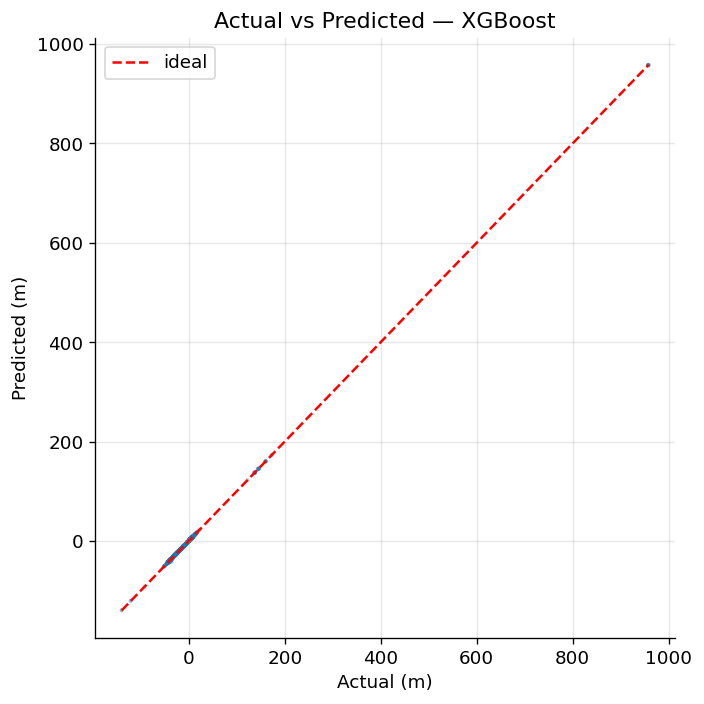

In [19]:
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
})
preds = {**model_level_preds,
         "Ensemble (all models)": ensemble_pred, BASELINE_NAME: persist_pred}
best_pred = np.asarray(preds[best_model_name], dtype=float)

rng = np.random.default_rng(SEED)
plot_n = min(5000, len(y_test))
sel = np.sort(rng.choice(len(y_test), plot_n, replace=False))

# 1) Actual vs Predicted (best model)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test[sel], best_pred[sel], s=6, alpha=0.3, edgecolor="none")
lims = [min(y_test[sel].min(), best_pred[sel].min()), max(y_test[sel].max(), best_pred[sel].max())]
ax.plot(lims, lims, "r--", lw=1.5, label="ideal")
ax.set(xlabel="Actual (m)", ylabel="Predicted (m)",
       title=f"Actual vs Predicted — {best_model_name}")
ax.legend(); plt.tight_layout(); plt.show()

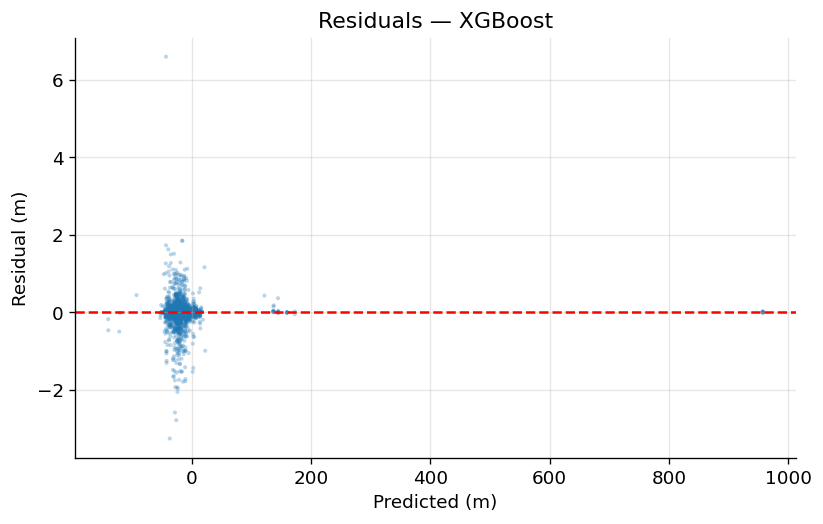

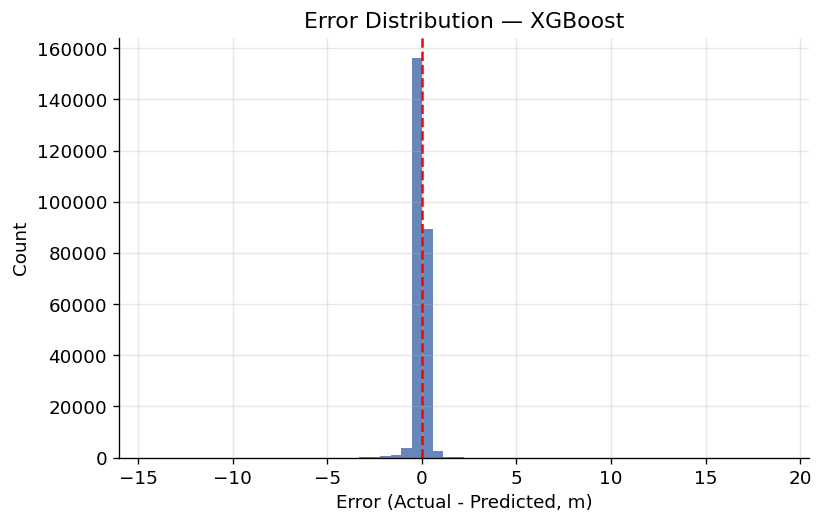

In [20]:
# 2) Residual plot (best model)
resid = y_test - best_pred
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(best_pred[sel], resid[sel], s=6, alpha=0.3, edgecolor="none")
ax.axhline(0, color="r", ls="--", lw=1.5)
ax.set(xlabel="Predicted (m)", ylabel="Residual (m)", title=f"Residuals — {best_model_name}")
plt.tight_layout(); plt.show()

# 3) Error histogram (best model)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(resid, bins=60, color="#4C72B0", alpha=0.85)
ax.axvline(0, color="r", ls="--", lw=1.5)
ax.set(xlabel="Error (Actual - Predicted, m)", ylabel="Count",
       title=f"Error Distribution — {best_model_name}")
plt.tight_layout(); plt.show()

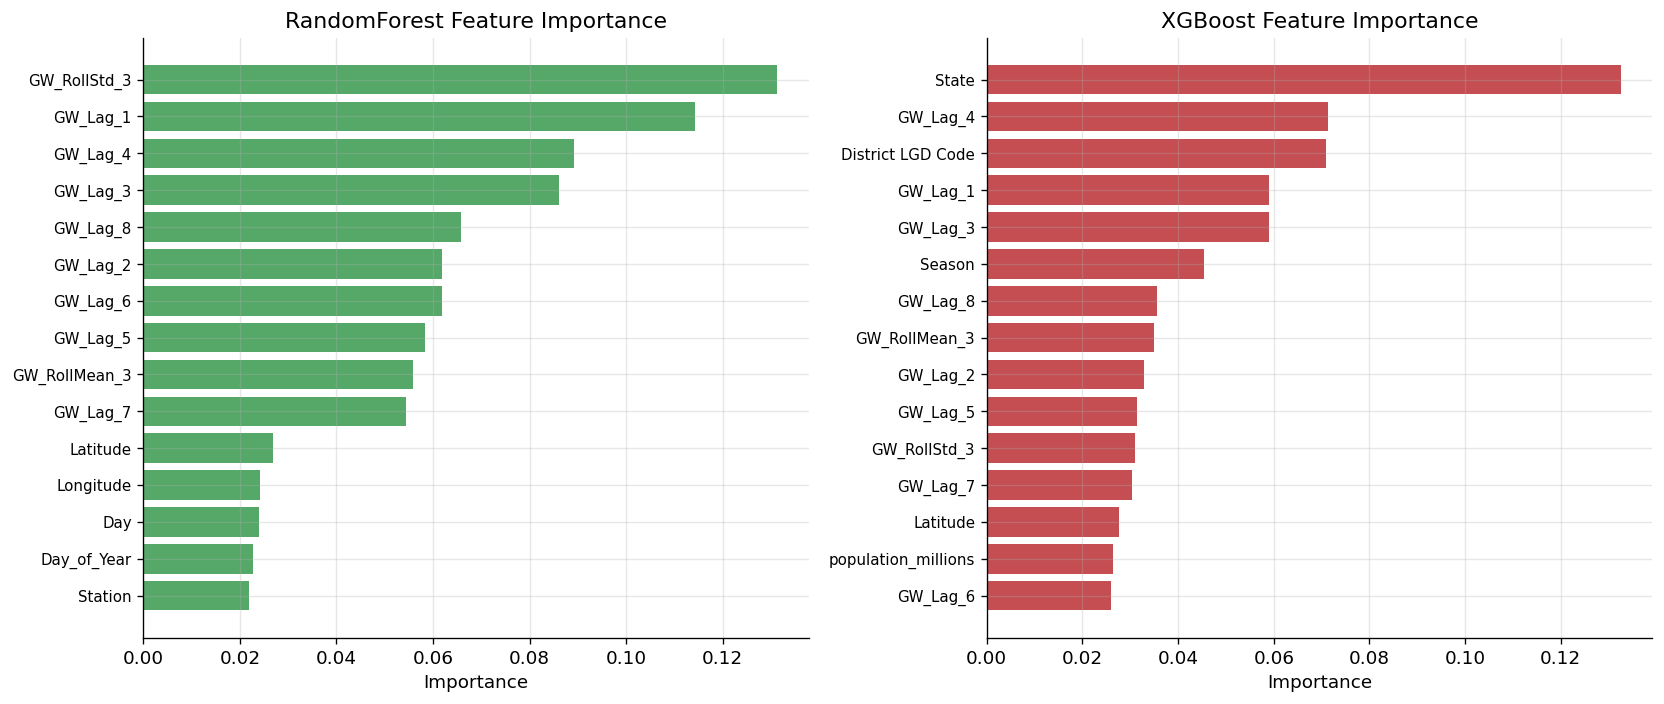

In [21]:
# 4 & 5) Feature importance — RandomForest and XGBoost
def importance_plot(ax, names, importances, title, color):
    order = np.argsort(importances)[::-1][:15]
    labels = [inv_safe.get(names[i], names[i]) for i in order]
    ax.barh(range(len(order)), np.array(importances)[order][::-1], color=color)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(labels[::-1], fontsize=9)
    ax.set(title=title, xlabel="Importance")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
importance_plot(axes[0], list(X_all.columns), best_rf.feature_importances_,
                "RandomForest Feature Importance", "#55A868")
importance_plot(axes[1], list(X_all.columns), best_xgb.feature_importances_,
                "XGBoost Feature Importance", "#C44E52")
plt.tight_layout(); plt.show()

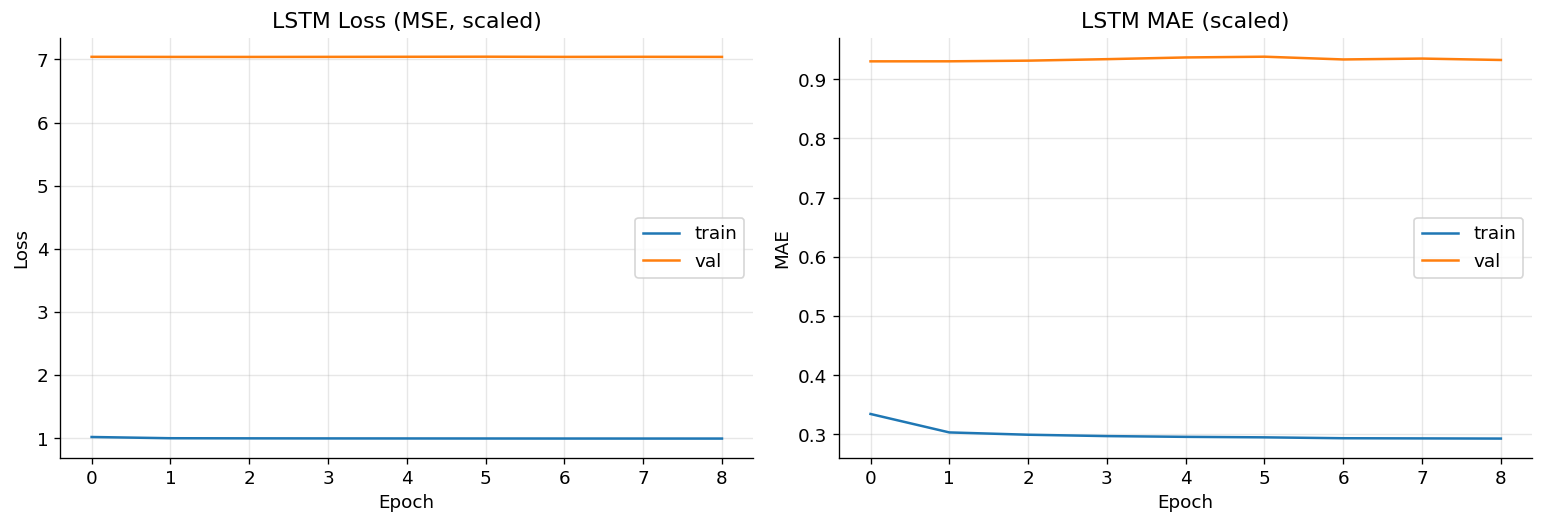

In [22]:
# 6 & 7) LSTM training / validation loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set(title="LSTM Loss (MSE, scaled)", xlabel="Epoch", ylabel="Loss"); axes[0].legend()
axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="val")
axes[1].set(title="LSTM MAE (scaled)", xlabel="Epoch", ylabel="MAE"); axes[1].legend()
plt.tight_layout(); plt.show()

## Error Diagnostic — What Drives RMSE?

RMSE is far larger than MAE, which means a few rows with large errors dominate it. This
lists the 10 worst predictions of the best model so those cases can be inspected (often
sensor spikes, station discontinuities, or genuine rapid drawdown events).

In [23]:
abs_err = np.abs(y_test - best_pred)
worst = np.argsort(abs_err)[::-1][:10]
worst_rows = test_idx[worst]
worst_tbl = pd.DataFrame({
    "Station": encoders[STATION_COL].inverse_transform(df.loc[worst_rows, STATION_COL].astype(int)),
    "Time": df.loc[worst_rows, TIME_COL].values,
    "Actual": y_test[worst],
    f"{best_model_name}_pred": np.round(best_pred[worst], 3),
    "AbsError": np.round(abs_err[worst], 3),
    "Prev_value(Lag1)": np.round(persist_pred[worst], 3),
})
print(f"Median abs error: {np.median(abs_err):.3f} m | 99th pct: {np.percentile(abs_err,99):.3f} m | max: {abs_err.max():.3f} m")
print(f"Rows with abs error > 5 m: {(abs_err > 5).sum()} of {len(abs_err)} ({(abs_err>5).mean()*100:.3f}%)")
display(worst_tbl)

Median abs error: 0.020 m | 99th pct: 1.106 m | max: 18.807 m
Rows with abs error > 5 m: 54 of 254812 (0.021%)


,Station,Time,Actual,XGBoost_pred,AbsError,Prev_value(Lag1)
0,Fatehgarh Sahib;SIRHIND;TEHALPUR;Govt. Elem. S...,2020-12-14 06:00:00,-8.000000,-26.807,18.807,-26.800
1,KAPURTHALA;PHAGWARA ;PHAGWARA ;RAWALPINDI;Janj...,2020-10-03 12:49:00,-30.040001,-15.684,14.356,-15.590
2,FEROZEPUR;FER;GHALL KHURD;MOHAKAM KHAN WALA;Go...,2020-11-04 12:00:00,-12.780000,-26.994,14.214,-27.000
3,GURDASPUR;DERA BABA NANAK ;SHEZADA KALNA;Panch...,2020-09-14 12:23:00,-18.600000,-4.983,13.617,-4.983
4,FEROZEPUR;FER;GHALL KHURD;MOHAKAM KHAN WALA;Go...,2020-10-21 14:22:00,-27.000000,-13.417,13.583,-13.390
5,GURDASPUR;DERA BABA NANAK ;SHEZADA KALNA;Panch...,2020-09-24 06:00:00,-18.270000,-5.184,13.086,-5.178
6,GURDASPUR;DERA BABA NANAK ;SHEZADA KALNA;Panch...,2020-09-19 12:00:00,-17.930000,-4.985,12.945,-5.031
7,GURDASPUR;DERA BABA NANAK ;SHEZADA KALNA;Panch...,2020-09-14 18:00:00,-5.186000,-17.808,12.622,-18.600
8,GURDASPUR;DERA BABA NANAK ;SHEZADA KALNA;Panch...,2020-09-26 06:00:00,-5.042000,-17.273,12.231,-17.310
9,GURDASPUR;DERA BABA NANAK ;SHEZADA KALNA;Panch...,2020-09-20 12:00:00,-5.113000,-17.010,11.897,-17.100


## Model Saving

RandomForest (`.joblib`), XGBoost (`.json`), LightGBM (`.joblib`), CatBoost (`.cbm`) and
the LSTM (`.keras`) are written to the working directory, along with the scalers (including
the delta scaler), encoders and feature lists needed for inference.

In [24]:
rf_path  = os.path.join(OUTPUT_DIR, "random_forest.joblib")
xgb_path = os.path.join(OUTPUT_DIR, "xgboost_model.json")
lgb_path = os.path.join(OUTPUT_DIR, "lightgbm_model.joblib")
cat_path = os.path.join(OUTPUT_DIR, "catboost_model.cbm")
art_path = os.path.join(OUTPUT_DIR, "preprocessing.joblib")

joblib.dump(best_rf, rf_path)
best_xgb.save_model(xgb_path)
joblib.dump(lgbm, lgb_path)
cat.save_model(cat_path)
lstm.save(ckpt_path)   # also written by ModelCheckpoint
joblib.dump({
    "target_scaler": target_scaler, "delta_scaler": delta_scaler, "static_scaler": static_scaler,
    "encoders": encoders, "feature_cols": feature_cols, "safe_map": safe_map,
    "static_cols": static_cols, "seq_cols_ordered": seq_cols_ordered,
    "lag_cols": lag_cols, "SEQ_LEN": SEQ_LEN, "target_col": TARGET_COL,
    "DELTA_TARGET": DELTA_TARGET, "lag1_col": safe_map["GW_Lag_1"],
}, art_path)

for p in [rf_path, xgb_path, lgb_path, cat_path, ckpt_path, art_path]:
    print(f"saved {p}  ({os.path.getsize(p)/1e6:.2f} MB)")

saved /kaggle/working/random_forest.joblib  (337.01 MB)
saved /kaggle/working/xgboost_model.json  (5.81 MB)
saved /kaggle/working/lightgbm_model.joblib  (4.19 MB)
saved /kaggle/working/catboost_model.cbm  (6.49 MB)
saved /kaggle/working/lstm_model.keras  (0.44 MB)
saved /kaggle/working/preprocessing.joblib  (0.05 MB)


## Prediction on Unseen Samples

Reload each saved model from disk and predict on a handful of held-out test rows to
confirm the artifacts are self-contained and usable for inference.

In [25]:
# Reload artifacts
art = joblib.load(art_path)
rf_loaded  = joblib.load(rf_path)
xgb_loaded = xgb.XGBRegressor(); xgb_loaded.load_model(xgb_path)
lgb_loaded = joblib.load(lgb_path)
cat_loaded = CatBoostRegressor(); cat_loaded.load_model(cat_path)
lstm_loaded = tf.keras.models.load_model(ckpt_path)

k = min(10, len(test_idx))
sample_rows = test_idx[-k:]

Xs = X_all.iloc[sample_rows]
lag1_s = lag1_all[sample_rows]
seq_s, stat_s = build_seq(sample_rows)

rf_p  = to_level(rf_loaded.predict(Xs), lag1_s)
xgb_p = to_level(xgb_loaded.predict(Xs), lag1_s)
lgb_p = to_level(lgb_loaded.predict(Xs), lag1_s)
cat_p = to_level(cat_loaded.predict(Xs), lag1_s)
lstm_p = to_level(unscale_y(lstm_loaded.predict({"sequence": seq_s, "static": stat_s}, verbose=0)), lag1_s)

pred_table = pd.DataFrame({
    "Station": encoders[STATION_COL].inverse_transform(df.loc[sample_rows, STATION_COL].astype(int))
               if STATION_COL in encoders else df.loc[sample_rows, STATION_COL].values,
    "Time": df.loc[sample_rows, TIME_COL].values,
    "Actual": np.round(y_all[sample_rows], 3),
    "RF": np.round(rf_p, 3), "XGB": np.round(xgb_p, 3), "LGB": np.round(lgb_p, 3),
    "Cat": np.round(cat_p, 3), "LSTM": np.round(lstm_p, 3),
})
pred_table["Ensemble"] = np.round(
    np.mean(np.stack([rf_p, xgb_p, lgb_p, cat_p, lstm_p]), axis=0), 3)
print("Predictions on unseen (most recent) test samples:")
display(pred_table)

2026-07-19 17:52:03.822768: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Predictions on unseen (most recent) test samples:


,Station,Time,Actual,RF,XGB,LGB,Cat,LSTM,Ensemble
0,LUDHIANA;Jagraon;JAGRAON;PABBIAN;Vet. Dispensary,2020-12-31 18:00:00,-21.0,-21.059,-21.042999,-21.109,-21.021,-20.980000,-21.043
1,LUDHIANA;DORAHA;PAYAL;GOVT. SR. SCHOOL,2020-12-31 18:00:00,-14.0,-14.009,-14.033000,-14.032,-14.042,-13.979000,-14.019
2,FARIDKOT;JAITU;KOT KAPURA;BEHBAL KALAN;P.L. BDPO,2020-12-31 18:00:00,-16.0,-16.006,-16.011000,-16.010,-16.008,-15.980000,-16.003
3,KAPURTHALA;SULTANPUR LODHI;HAZIPUR Panchyat Ghar,2020-12-31 18:00:00,-7.0,-7.011,-7.024000,-7.061,-7.036,-6.996000,-7.026
4,KAPURTHALA;SULTANPUR LODHI;BAURIL HARNAMPUR;Go...,2020-12-31 18:00:00,-17.0,-17.025,-17.021000,-17.028,-17.037,-16.993999,-17.021
5,TARN TARAN ;CHOLA SAHIB;FATEHABAD;Primary helt...,2020-12-31 18:00:00,-20.0,-20.020,-19.979000,-19.961,-19.954,-19.979000,-19.978
6,KAPURTHALA;PHAGWARA;SANGATPUR;VET. HOSP.,2020-12-31 18:00:00,-22.0,-22.011,-22.000000,-22.003,-21.997,-21.989000,-22.000
7,TARN TARAN;PATTI;PATTI;VET. HOSP.,2020-12-31 18:00:00,-25.0,-25.017,-24.982000,-24.958,-24.948,-24.989000,-24.979
8,GURDASPUR;GURDASPUR;DINA NAGAR;JHABKRA;Vet. Ho...,2020-12-31 21:00:00,-3.0,-2.997,-2.998000,-2.985,-2.993,-2.986000,-2.992
9,ROPAR;ROPAR;ROPAR ;ATTARI;Govt. Sr. Sec. School,2020-12-31 22:15:00,-5.0,-5.010,-4.962000,-4.959,-5.144,-4.995000,-5.014


## Deployable Predictors — Type Features In, Get a Level Out

Two standalone models that predict the **absolute level directly** (no delta
reconstruction), so you can call them with a handful of feature values:

- **Context-only** — location, date, population, station/district. Works with *no past
  readings*, so you can predict for a site/date with no history. Less accurate.
- **With-history** — the above plus the recent `GW_Lag_*` readings. Most accurate.

The gap between their test scores below is exactly the value the recent-history signal adds.

In [26]:
# Feature sets (predict LEVEL directly here, unlike the delta models above)
context_feature_names = [c for c in feature_cols
                         if c not in (lag_cols + ["GW_RollMean_3", "GW_RollStd_3"])]
full_feature_names = list(feature_cols)
ctx_cols  = [safe_map[c] for c in context_feature_names]
full_cols = [safe_map[c] for c in full_feature_names]
cat_task2 = "GPU" if (HAS_NVIDIA_GPU and len(GPUS) > 0) else "CPU"

def train_level_model(cols):
    m = CatBoostRegressor(
        loss_function=f"Huber:delta={HUBER_DELTA}", eval_metric="RMSE",
        iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=3.0,
        random_seed=SEED, task_type=cat_task2, thread_count=N_CORES,
        od_type="Iter", od_wait=50, verbose=0)
    m.fit(X_train[cols], y_train, eval_set=(X_val[cols], y_val), use_best_model=True)
    return m

print("Training context-only predictor..."); model_context = train_level_model(ctx_cols)
print("Training with-history predictor...");  model_full    = train_level_model(full_cols)

print("\nDeployable predictor comparison (predicting absolute level on the test set):")
for name, m, cols in [("Context-only (no history)", model_context, ctx_cols),
                      ("With-history (uses lags)",  model_full,    full_cols)]:
    p = m.predict(X_test[cols])
    print(f"  {name:26s}  RMSE={np.sqrt(mean_squared_error(y_test,p)):.3f}  "
          f"MAE={mean_absolute_error(y_test,p):.3f}  R2={r2_score(y_test,p):.4f}")
print(f"\nContext-only uses {len(context_feature_names)} features; "
      f"with-history uses {len(full_feature_names)}.")

Training context-only predictor...
Training with-history predictor...

Deployable predictor comparison (predicting absolute level on the test set):
  Context-only (no history)   RMSE=436.831  MAE=261.644  R2=-96.5385
  With-history (uses lags)    RMSE=320.754  MAE=245.865  R2=-51.5888

Context-only uses 26 features; with-history uses 36.


### `predict_groundwater(...)` — pass any subset of features

Supply whatever you know as keyword arguments (original column names, e.g.
`State="Bihar"`, `Latitude=24.87`, `Month=6`, `GW_Lag_1=9.5`). Anything you omit is filled
with a sensible default (training median for numbers, most-common category for text).
Set `use_history=True` to use the accurate model (provide the `GW_Lag_*` values).

In [27]:
# Defaults for anything the caller omits
num_defaults = {c: float(df.loc[train_idx, c].median()) for c in feature_cols if c not in encoders}
cat_defaults = {c: int(df.loc[train_idx, c].mode().iloc[0]) for c in encoders}

def _encode(col, val):
    if col in encoders and isinstance(val, str):
        le = encoders[col]
        return int(le.transform([val])[0]) if val in le.classes_ else cat_defaults[col]
    return val

def predict_groundwater(use_history=False, **inputs):
    # Warn about unknown kwargs so typos are visible
    unknown = [k for k in inputs if k not in feature_cols]
    if unknown:
        print("  [note] ignoring unknown features:", unknown)
    row = {}
    for col in feature_cols:
        s = safe_map[col]
        if col in inputs:            row[s] = _encode(col, inputs[col])
        elif col in encoders:        row[s] = cat_defaults[col]
        else:                        row[s] = num_defaults.get(col, 0.0)
    X1 = pd.DataFrame([row]).astype("float32")
    if use_history:
        return float(model_full.predict(X1[full_cols])[0])
    return float(model_context.predict(X1[ctx_cols])[0])

# --- Examples ---
print("Context-only (location + date + population, no past readings):")
print("  predicted level =", round(predict_groundwater(
    State="Bihar", District="AURANGABAD", Latitude=24.87, Longitude=84.21,
    Year=2020, Month=6, Season="Monsoon"), 3), "m")

print("\nWith recent history (most accurate):")
print("  predicted level =", round(predict_groundwater(
    use_history=True, GW_Lag_1=9.5, GW_Lag_2=9.5, GW_Lag_3=9.54,
    Latitude=24.87, Longitude=84.21, Year=2020, Month=6, Season="Monsoon"), 3), "m")

Context-only (location + date + population, no past readings):
  predicted level = 10.214 m

With recent history (most accurate):
  predicted level = 211.3 m


### Interactive form (Kaggle)

Fill the fields and click **Predict**. Requires `ipywidgets` (available on Kaggle); if it
isn't present the notebook falls back to the `predict_groundwater(...)` calls above.

In [28]:
try:
    import ipywidgets as W
    from IPython.display import display as _display

    states = list(encoders[STATE_COL].classes_) if (STATE_COL := "State") in encoders else []
    seasons = list(encoders["Season"].classes_) if "Season" in encoders else ["Monsoon"]
    w_state  = W.Dropdown(options=states or ["(n/a)"], description="State")
    w_lat    = W.FloatText(value=24.87, description="Latitude")
    w_lon    = W.FloatText(value=84.21, description="Longitude")
    w_month  = W.IntSlider(value=6, min=1, max=12, description="Month")
    w_year   = W.IntText(value=2020, description="Year")
    w_season = W.Dropdown(options=seasons, description="Season")
    w_hist   = W.Checkbox(value=False, description="Use recent history (lags)")
    w_lag1   = W.FloatText(value=9.5, description="GW_Lag_1")
    w_out    = W.Output()

    def _go(_):
        with w_out:
            w_out.clear_output()
            kw = dict(State=w_state.value, Latitude=w_lat.value, Longitude=w_lon.value,
                      Month=w_month.value, Year=w_year.value, Season=w_season.value)
            if w_hist.value:
                kw.update(GW_Lag_1=w_lag1.value, GW_Lag_2=w_lag1.value, GW_Lag_3=w_lag1.value)
            val = predict_groundwater(use_history=w_hist.value, **kw)
            print(f"Predicted groundwater level: {val:.3f} m "
                  f"({'with-history' if w_hist.value else 'context-only'} model)")

    btn = W.Button(description="Predict", button_style="success"); btn.on_click(_go)
    _display(W.VBox([w_state, w_lat, w_lon, w_year, w_month, w_season, w_hist, w_lag1, btn, w_out]))
    _go(None)
except Exception as e:
    print("ipywidgets unavailable here — call predict_groundwater(...) directly. Detail:", e)

### Save the deployable predictors

In [29]:
ctx_path  = os.path.join(OUTPUT_DIR, "predictor_context.cbm")
full_pth  = os.path.join(OUTPUT_DIR, "predictor_with_history.cbm")
model_context.save_model(ctx_path)
model_full.save_model(full_pth)
joblib.dump({"context_feature_names": context_feature_names,
             "full_feature_names": full_feature_names,
             "num_defaults": num_defaults, "cat_defaults": cat_defaults,
             "safe_map": safe_map, "encoders": encoders},
            os.path.join(OUTPUT_DIR, "predictor_meta.joblib"))
for p in [ctx_path, full_pth]:
    print(f"saved {p}  ({os.path.getsize(p)/1e6:.2f} MB)")

saved /kaggle/working/predictor_context.cbm  (0.02 MB)
saved /kaggle/working/predictor_with_history.cbm  (0.02 MB)


## Final Summary

In [30]:
print("=" * 64)
print("GROUNDWATER LEVEL PREDICTION — FINAL RESULTS")
print("=" * 64)
summary = res_df.copy()
summary.insert(0, "Model", summary.index)
print(summary.round(4).to_string(index=False))
print("-" * 64)
best = res_df.loc[best_model_name]
print(f"BEST MODEL: {best_model_name}")
print(f"  RMSE={best['RMSE']:.4f}  MAE={best['MAE']:.4f}  "
      f"R2={best['R2']:.4f}  MAPE={best['MAPE']:.2f}%")
print("=" * 64)

GROUNDWATER LEVEL PREDICTION — FINAL RESULTS
                Model   RMSE    MAE  R2   MAPE  Training Time (s)
              XGBoost 0.2729 0.0895 1.0 0.7658           131.1137
             LightGBM 0.2762 0.0905 1.0 0.7890            23.1610
             CatBoost 0.2766 0.0916 1.0 0.7819            21.0896
Ensemble (all models) 0.2770 0.0883 1.0 0.7811          2668.6174
         RandomForest 0.2865 0.0913 1.0 0.7620          2438.2172
  Persistence (Lag-1) 0.3091 0.0922 1.0 0.7948             0.0000
                 LSTM 0.3100 0.1004 1.0 0.9795            55.0359
----------------------------------------------------------------
BEST MODEL: XGBoost
  RMSE=0.2729  MAE=0.0895  R2=1.0000  MAPE=0.77%


In [34]:
!zip -r folder .zip /kaggle/working/ 

	zip warning: name not matched: .zip
updating: kaggle/working/ (stored 0%)
updating: kaggle/working/predictor_context.cbm (deflated 69%)
updating: kaggle/working/catboost_info/ (stored 0%)
updating: kaggle/working/catboost_info/time_left.tsv (deflated 48%)
updating: kaggle/working/catboost_info/learn_error.tsv (deflated 46%)
updating: kaggle/working/catboost_info/catboost_training.json (deflated 66%)
updating: kaggle/working/catboost_info/learn/ (stored 0%)
updating: kaggle/working/catboost_info/learn/events.out.tfevents (deflated 76%)
updating: kaggle/working/catboost_info/test/ (stored 0%)
updating: kaggle/working/catboost_info/test/events.out.tfevents (deflated 76%)
updating: kaggle/working/catboost_info/test_error.tsv (deflated 47%)
updating: kaggle/working/catboost_info/tmp/ (stored 0%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
updating: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 65%)
updating: kaggle/working/predictor_meta.joblib (deflate

In [1]:
from Ipython.display import FileLink 
FileLink(r'folder.zip')

ModuleNotFoundError: No module named 'Ipython'